<a href="https://colab.research.google.com/github/zhouqiang06/ADVISE/blob/main/Demo_of_analysis_in_manuscript.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Integrated Analysis Pipeline
This notebook demonstrates a machine learning and interpretability workflow that implements data preprocessing, Deep Neural Network (DNN) optimization via Optuna, feature attributions via Captum, and verification using Symbolic Regression.

## 1. Environment Setup & Dependencies

In [ ]:
import os
import sys
from glob import glob
from datetime import datetime

import numpy as np
import pandas as pd
from sklearn import preprocessing
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.metrics import r2_score

import torch
import torch.nn as nn
import torch.optim as optim

import time
import json
import joblib

In [ ]:
# Install optimization and interpretability frameworks
!pip install optuna captum pysr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 17.4 MB/s eta 0:00:00


## 2. Global Configuration Variables

In [ ]:
DATA_PATH = './ForestTypevalid_climate_driver_data.csv'
N_VAR = 5 # number of X variables

SAVE_PATH = './outputs'
os.makedirs(SAVE_PATH, exist_ok=True)

## 3. Simulation Model and Data Preprocessing
Implements the ecosystem calculation mechanics for Net Primary Production (NPP) based on *Del Grosso et al. (2008)*.

In [ ]:
###
# Del Grosso, S., Parton, W., Stohlgren, T., Zheng, D., Bachelet, D., Prince, S., Hibbard, K. and Olson, R., 2008.
# Global potential net primary production predicted from vegetation class, precipitation, and temperature.
# Ecology, 89(8), pp.2117-2126.###
def cal_TNPP(prcp, tmean, verbose=False):
  """
  Calculates Net Primary Production based on Del Grosso et al. (2008).
  Args:
      prcp (array): Precipitation values.
      tmean (array): Mean temperature values.
      verbose (bool): If True, returns individual calculation components.
    "
  """
  # Vectorized calculation
  f_MAP = 0.551 * prcp ** 1.055 / np.exp(0.000306 * prcp)
  f_MAT = 2540 / (1 + np.exp(1.584 - 0.0622 * tmean))
  npp = np.minimum(f_MAP, f_MAT)

  if verbose:
    # Returns contributions for plotting
    return npp, [np.where(f_MAP < f_MAT, f_MAP, 0), np.where(f_MAT <= f_MAP, f_MAT, 0)]
  return npp


def make_simudata_NPP(file_path, nx=0.0, ny=0.0, noise_x='all'):
  """
  Loads climate metrics and adds controlled Gaussian noise to inputs or targets.
  """
  df = pd.read_csv(file_path)

  df = df[df['prcp'] > 0] # make sure precipitation is greater than 0
  df = df[df['tmean'] > 0] # make sure tmean is greater than 0
  df_y = cal_TNPP(df['prcp'].values, df['tmean'].values)
  ## add random noise to x variables
  if nx > 0:
    for (columnName, columnData) in df.iteritems():
      if (noise_x == 'all') or (columnName in noise_x):
        print('Column Name, noise level: ', columnName, nx)
        raw_x = columnData.values
        df[columnName] = np.random.normal(loc=0, scale=nx * np.std(raw_x), size=raw_x.shape) + raw_x

  df['y'] = df_y
  ## add random noise to y variables
  if ny > 0:
    raw_y = df_y
    df['y'] = np.random.normal(loc=0, scale=ny * np.std(raw_y), size=raw_y.shape) + raw_y

  var_names = df.columns.values.tolist()

  return df, var_names

def preprocessing_simudata(dataset, pca=True, standerize=True, train_portion=0.8, min_train=3000):
  """Shuffles, splits, and standardizes feature vectors into train and test spaces.

  Args:
      dataset (array): orginal data
      pca (bool, optional): If conduct PCA (Principal component analysis) transformation. Defaults to True.
      standerize (bool, optional): If standerize X variables. Defaults to True.
      train_portion (float, optional): split training test data. Defaults to 0.8.

  Returns:
      train_x (array): Preprocessed X training data
      train_y (array): Preprocessed Y training data
      test_x (array): Preprocessed X test data
      test_y (array): Preprocessed Y test data
      scaler (object): The standardization scaler (see sklearn.preprocessing.StandardScaler)
  """
  # preview_simudata(dataset)
  # Make sure the last column is y
  dataset = dataset.reset_index(drop=True)
  shuf_idx = dataset.sample(frac=1).index  # Shuffle index of dataframe
  # print('idx:', np.min(shuf_idx), np.max(shuf_idx), len(dataset))
  full_feature = dataset.iloc[shuf_idx]  # Shuffle dataframe
  np.save(os.path.join(SAVE_PATH, 'simu_shuf_idx.npy'), shuf_idx)
  full_feature.iloc[:, :-1].to_csv(os.path.join(SAVE_PATH, 'all_fea_raw.csv'), index=False)
  # full_feature = dataset
  n_training = max(int(len(full_feature) * train_portion), min_train)

  if standerize:
    x_stack = full_feature.iloc[:, :-1].values.copy()  # returns a numpy array
    scaler = preprocessing.StandardScaler()
    x_scaled = scaler.fit_transform(x_stack)
    full_feature.iloc[:, :-1] = x_scaled

  else:
    scaler = None

  dataset_x = full_feature.iloc[:, :-1].values.copy()
  dataset_y = full_feature.iloc[:, -1].values.copy()
  train_x = dataset_x[:n_training, :].copy()
  train_y = dataset_y[:n_training].copy()

  test_x = dataset_x[n_training:, :].copy()
  test_y = dataset_y[n_training:].copy()
  return train_x, train_y, test_x, test_y, scaler

In [ ]:
# Execute data preprocessing pipeline
dataset, var_names = make_simudata_NPP(DATA_PATH, nx=0, ny=0, noise_x='all')
train_x_np, train_y_np, test_x_np, test_y_np, scaler = preprocessing_simudata(
    dataset, standerize=True, train_portion=0.8
)

# Stack arrays and serialize datasets
all_fea_np = np.vstack((train_x_np, test_x_np))
y_fea_np = np.vstack((train_y_np[:, np.newaxis], test_y_np[:, np.newaxis]))
np.save(os.path.join(SAVE_PATH, 'all_fea.npy'), all_fea_np)
np.save(os.path.join(SAVE_PATH, 'y_fea.npy'), y_fea_np)

if scaler is not None:
    all_fea_raw = scaler.inverse_transform(all_fea_np)
    np.save(os.path.join(SAVE_PATH, 'all_fea_raw.npy'), all_fea_raw)
    joblib.dump(scaler, os.path.join(SAVE_PATH, 'torch_scaler.bin'))

# Construct PyTorch variables
train_x = torch.from_numpy(train_x_np).float()
train_y = torch.from_numpy(train_y_np).float().unsqueeze(1)
test_x = torch.from_numpy(test_x_np).float()
test_y = torch.from_numpy(test_y_np).float().unsqueeze(1)
all_fea = torch.from_numpy(all_fea_np).float()

## 4. Deep Neural Network Optimization & Training
Defines a dynamic network architecture evaluated dynamically across continuous trails using an Optuna Study.

In [ ]:
import optuna

class RegressionDNN(nn.Module):
    def __init__(self, input_dim, hidden_dims):
        super().__init__()

        layers = []
        prev_dim = input_dim

        # Dynamically build hidden layers
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.ReLU())
            prev_dim = h_dim

        # Output layer
        layers.append(nn.Linear(prev_dim, 1))

        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)

def objective(trial):
    # # Structural architecture search boundaries
    # Suggest how deep the network should be (e.g., 1 to 5 hidden layers)
    num_layers = trial.suggest_int("num_layers", 1, 5)

    hidden_dims = []
    for i in range(num_layers):
        # Dynamically suggest units for each individual layer
        # Lower bound decreases for deeper layers to mimic a funnel structure
        units = trial.suggest_int(f"units_layer_{i}", 16, 512)
        hidden_dims.append(units)

    # Hyperparameter tuning variables
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    # Data Setup
    train_ds = torch.utils.data.TensorDataset(train_x, train_y)
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    # Model & Optimization Setup
    model = RegressionDNN(input_dim=train_x.shape[1], hidden_dims=hidden_dims)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    # Training Loop
    for epoch in range(50):
        model.train()
        for b_x, b_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(b_x), b_y)
            loss.backward()
            optimizer.step()

        # Evaluation Loop
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(test_x), test_y).item()

        # Optuna Pruning Check
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return val_loss


[I 2026-06-02 15:36:43,286] A new study created in memory with name: no-name-5ecefdab-bec4-4262-a91f-49f54ba268de
[I 2026-06-02 15:38:05,956] Trial 0 finished with value: 84.48538970947266 and parameters: {'num_layers': 3, 'units_layer_0': 276, 'units_layer_1': 458, 'units_layer_2': 345, 'lr': 0.00010484177743037651, 'batch_size': 128, 'weight_decay': 1.0188150726511775e-05}. Best is trial 0 with value: 84.48538970947266.
[I 2026-06-02 15:38:32,115] Trial 1 finished with value: 898.3640747070312 and parameters: {'num_layers': 1, 'units_layer_0': 423, 'lr': 0.0010264278369361316, 'batch_size': 32, 'weight_decay': 0.0006227441139879001}. Best is trial 0 with value: 84.48538970947266.
[I 2026-06-02 15:43:04,720] Trial 2 finished with value: 7.772390842437744 and parameters: {'num_layers': 4, 'units_layer_0': 287, 'units_layer_1': 510, 'units_layer_2': 176, 'units_layer_3': 212, 'lr': 0.0007265777876182945, 'batch_size': 64, 'weight_decay': 0.002539118285486163}. Best is trial 2 with value


Optimization Complete. Best Params: {'num_layers': 2, 'units_layer_0': 346, 'units_layer_1': 301, 'lr': 0.004988824989451019, 'batch_size': 32, 'weight_decay': 2.430523894359511e-05}


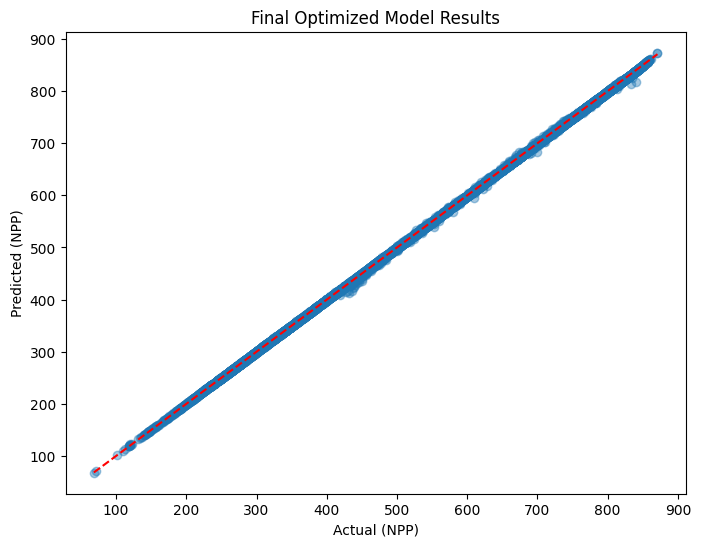

In [ ]:
# Execute Model Optimization Study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)
best_params = study.best_trial.params
print(f"\nOptimization Complete. Best Params: {best_params}")

# Reconstruct the optimized architecture config
best_hidden_dims = []
num_layers = best_params["num_layers"]
for i in range(num_layers):
    best_hidden_dims.append(best_params[f"units_layer_{i}"])
final_model = RegressionDNN(input_dim=train_x.shape[1], hidden_dims=best_hidden_dims)
optimizer = optim.Adam(
    final_model.parameters(),
    lr=best_params["lr"],
    # weight_decay=best_params["weight_decay"]
)
criterion = nn.MSELoss()
final_ds = torch.utils.data.TensorDataset(train_x, train_y)
final_loader = torch.utils.data.DataLoader(
    final_ds,
    batch_size=best_params["batch_size"],
    shuffle=True
)

# Final convergence execution phase
final_model.train()
for epoch in range(100):
    for b_x, b_y in final_loader:
        optimizer.zero_grad()
        loss = criterion(final_model(b_x), b_y)
        loss.backward()
        optimizer.step()

# Save optimized states along with network parameters
checkpoint = {
    'hidden_dims': best_hidden_dims,
    'state_dict': final_model.state_dict(),
    'scaler_param': best_params
}
torch.save(checkpoint, os.path.join(SAVE_PATH, 'final_regression_model.pt'))

# Performance predictions generation
final_model.eval()
input_data = all_fea.clone().detach().requires_grad_(True)
predictions = final_model(input_data)

# Save Predictions
pred_np = predictions.detach().numpy().squeeze()
np.save(os.path.join(SAVE_PATH, 'predictions.npy'), pred_np)

# Performance visualization diagnostic plot
plt.figure(figsize=(8, 6))
plt.scatter(y_fea_np.squeeze(), pred_np, alpha=0.4)
plt.plot([y_fea_np.min(), y_fea_np.max()], [y_fea_np.min(), y_fea_np.max()], 'r--')
plt.xlabel('Actual (NPP)')
plt.ylabel('Predicted (NPP)')
plt.title('Final Optimized Model Results')
plt.show()

## 5. Derivative Layer Attributions (previous ADVISE Method)

In [ ]:
def get_model_contributions_torch(model, x_data):
    """
    Extracts parameter signals across intermediate feedforward network layers
    using forward-pass linear structural activation hooks.
    """
    model.eval()
    # Ensure x_data is a torch tensor
    if isinstance(x_data, np.ndarray):
        x_tensor = torch.from_numpy(x_data).float()
    else:
        x_tensor = x_data.float()

    # 1. Capture Activations using Hooks
    # This will capture outputs of Linear layers and ReLU layers sequentially.
    activations = []
    def hook_fn(module, input, output):
        activations.append(output.detach())

    hooks = []
    for layer in model.layers:
        if isinstance(layer, nn.ReLU) or isinstance(layer, nn.Linear):
            hooks.append(layer.register_forward_hook(hook_fn))

    # Run forward pass to trigger hooks
    with torch.no_grad():
        _ = model(x_tensor)

    # Remove hooks immediately
    for h in hooks:
        h.remove()

    # 2. Extract Weights and Biases, convert to torch tensors
    linears = [l for l in model.layers if isinstance(l, nn.Linear)]
    W = [l.weight.detach().t() for l in linears] # Transpose for (in, out), keep as tensor
    b = [l.bias.detach() for l in linears]      # Keep as tensor

    # 3. Create masks from ReLU outputs
    # Activations captured: [Linear1_out, ReLU1_out, Linear2_out, ReLU2_out, ..., LinearLast_out]
    # Masks should be generated from the ReLU outputs and the final Linear output.
    masks = []
    # Loop through activations to get ReLU outputs (indices 1, 3, 5, ...).
    # Exclude the very last activation which is the final linear output.
    for k in range(1, len(activations) - 1, 2):
        masks.append((activations[k] > 0).float())

    # Add a mask for the final linear output (similar to Keras behavior).
    # This applies a ReLU-like mask to the final prediction, effectively forcing contributions to be positive.
    masks.append((activations[-1] > 0).float())

    num_samples, num_vars = x_data.shape
    contributions = torch.zeros((num_samples, num_vars), device=x_tensor.device)

    # 4. Calculate contribution for each input variable independently
    for i in range(num_vars):
        # Initial 'signal': i-th variable * its weights in first layer
        # x_tensor[:, i:i+1] is (N, 1), W[0][i, :] is (out_features, in_features)
        # W[0][i, :] will select the i-th row, so it needs to be W[0][:, i]
        # Or, W[0].t()[i, :] if W[0] is (out_features, in_features)
        # Given W is already transposed to (in, out), W[0][i, :] is correct here.
        val = x_tensor[:, i:i+1] * W[0][i, :]
        val = val * masks[0] # Mask applies after the first linear layer's ReLU

        # Propagate through hidden layers
        for j in range(1, len(W) - 1):
            val = torch.matmul(val, W[j]) * masks[j]

        # Final output layer
        val = val * W[-1].t() * masks[-1]
        contributions[:, i] = torch.sum(val, dim=1) # Use torch.sum

    # 5. Calculate Bias contribution
    # Start with first layer bias, repeated for all samples
    bias_sig = b[0].unsqueeze(0).repeat(num_samples, 1)
    bias_sig = bias_sig * masks[0]

    for j in range(1, len(W) - 1):
      bias_sig = (torch.matmul(bias_sig, W[j]) + b[j].unsqueeze(0)) * masks[j] # Use unsqueeze(0) for bias to match broadcasting

    bias_cont = torch.sum(bias_sig * W[-1].t(), dim=1) + b[-1]

    return torch.cat((contributions, bias_cont.unsqueeze(1)), dim=1).numpy()

def get_var_contr_raw(fea_x, coef_arr, scaler=None, return_bias=False):
  """Convert the variable contribution of input X (after preprocessing) to contribution of original X (before preprocessing).

  Args:
    fea_x (array): input X
    coef_arr (array): contribution of input X
    scaler (object, optional): The standardization scaler (see sklearn.preprocessing.StandardScaler). Defaults to None.
    pca (object, optional): The PCA object (see sklearn.decomposition.PCA). Defaults to None.
    return_bias (bool, optional): If returnt the DNN model bias (intercepts of linear transformation). Defaults to False.

  Returns:
    array: contribution of original X
  """
  slope_arr = coef_arr[:, :-1] / (fea_x + sys.float_info.epsilon) # calcualte the slope for input X variables
  slope_arr_raw = slope_arr.copy()

  raw_x = fea_x.copy()
  if scaler is not None: # reverse the standardization
    raw_x = scaler.inverse_transform(raw_x)
    if return_bias:
      return np.concatenate((raw_x * slope_arr_raw / scaler.scale_ - scaler.mean_ / scaler.scale_ * slope_arr_raw, coef_arr[:, -1].reshape(-1, 1)), axis=1)# raw_x * slope_arr_raw / scaler.scale_ - scaler.mean_ / scaler.scale_ * slope_arr_raw, coef_arr[:, -1]
    else:
      return raw_x * slope_arr_raw / scaler.scale_ - scaler.mean_ / scaler.scale_ * slope_arr_raw
  if return_bias:
    return np.concatenate((raw_x * slope_arr_raw, coef_arr[:, -1].reshape(-1, 1)), axis=1) # raw_x * slope_arr_raw, coef_arr[:, -1]
  else:
    return raw_x * slope_arr_raw  # - scaler.mean_ / scaler.scale_ * slope_arr_raw


def get_var_slopes_raw(fea_x, coef_arr, scaler=None):
  """Calculate variable slope for orginal X variables.

  Args:
      fea_x (array): input X variables (after preprocessing)
      coef_arr (array): contribution for input X variables
      scaler (object, optional): The standardization scaler (see sklearn.preprocessing.StandardScaler). Defaults to None.
      pca (object, optional): The PCA object (see sklearn.decomposition.PCA). Defaults to None.

  Returns:
      array: variable slope
  """
  slope_arr = coef_arr[:, :-1] / (fea_x + sys.float_info.epsilon) # calcualte the slope for input X variables
  slope_arr_raw = slope_arr.copy()
  if scaler is not None:
    slope_arr_raw = slope_arr_raw / scaler.scale_ # reverse the standardization scale
  return slope_arr_raw

## 6. Multi-Framework Feature Attribution Analysis
Runs feature sensitivity profiles using continuous gradient tracking engines from Captum.

In [ ]:
from captum.attr import LRP, Lime, IntegratedGradients, GradientShap, DeepLiftShap

# 1. PyTorch Native Autograd Evaluation
start_time = time.time()
gradients_scaled = torch.autograd.grad(
    outputs=predictions,
    inputs=input_data,
    grad_outputs=torch.ones_like(predictions),
    retain_graph=True,
    create_graph=False
)[0].detach().numpy()

torch.save(final_model.state_dict(), os.path.join(SAVE_PATH, 'model_state.pth'))
torch.save(final_model, os.path.join(SAVE_PATH, 'entire_model.pth'))

## Unscale the Gradients
# If x_scaled = (x_raw - mean) / std,
# then d(y)/d(x_raw) = d(y)/d(x_scaled) * (1 / std)
if scaler is not None:
    # scaler.scale_ contains the standard deviation for each feature
    input_std = scaler.scale_
    gradients_unscaled = gradients_scaled / input_std
else:
    gradients_unscaled = gradients_scaled
print(f"Time taken for auto-grad: {time.time() - start_time} seconds")
print('Export dataset')
np.save(os.path.join(SAVE_PATH, 'autograd_scaled.npy'), gradients_scaled) # Export input X data
np.save(os.path.join(SAVE_PATH, 'autograd_unscaled.npy'), gradients_unscaled) # Export input X data

# 2. Historical ADVISE Evaluation
start_time = time.time()
coef_arr = get_model_contributions_torch(final_model, all_fea)
contribution_arr = get_var_contr_raw(all_fea_np, coef_arr, scaler=scaler, return_bias=True)
partial_derivative_arr = get_var_slopes_raw(all_fea_np, coef_arr, scaler=scaler)
print(f"Time taken for ADVISE (old approach): {time.time() - start_time} seconds")
# np.save(os.path.join(SAVE_PATH, 'coef_arr.npy'), coef_arr) # Export model contribution data
# np.save(os.path.join(SAVE_PATH, 'contribution_arr.npy'), contribution_arr) # Export input contribution data
# np.save(os.path.join(SAVE_PATH, 'partial_derivative_arr.npy'), partial_derivative_arr) # Export input partial derivative data

# 3. Captum Framework Inferences
# LRP
from captum.attr import LRP #https://captum.ai/api/lrp.html
start_time = time.time()
lrp_linear_relu = LRP(final_model)
lrp_relevance = lrp_linear_relu.attribute(all_fea).detach().numpy()
print(f"Time taken for LRP: {time.time() - start_time} seconds")
np.save(os.path.join(SAVE_PATH, 'lrp_relevance.npy'), lrp_relevance) # Export input X data

# Lime
from captum.attr import Lime #https://captum.ai/api/lime.html
start_time = time.time()
lime_linear_relu = Lime(final_model)
lime_relevance = lime_linear_relu.attribute(all_fea).detach().numpy()
print(f"Time taken for Lime: {time.time() - start_time} seconds")
np.save(os.path.join(SAVE_PATH, 'Lime_attr.npy'), lime_relevance) # Export input X data

# Integrated Gradients
from captum.attr import IntegratedGradients #https://captum.ai/api/integrated_gradients.html
start_time = time.time()
ig_linear_relu = IntegratedGradients(final_model)
ig_relevance = ig_linear_relu.attribute(all_fea).detach().numpy()
print(f"Time taken for IntegratedGradients: {time.time() - start_time} seconds")
np.save(os.path.join(SAVE_PATH, 'IntegratedGradients_attr.npy'), ig_relevance) # Export input X data

# SHAP
from captum.attr import GradientShap #https://captum.ai/api/gradient_shap.html
start_time = time.time()
# 1. Define Baseline Distribution
# Instead of random noise, we use a representative subset of your training data
# 100-200 samples is usually sufficient for a stable SHAP distribution
n_baseline = 100
indices = np.random.choice(len(train_x), n_baseline, replace=False)
baseline_dist = train_x[indices]
# 2. Initialize Explainer
g_shap = GradientShap(final_model)
# 3. Process in Batches (to prevent Out of Memory errors)
start_time = time.time()
batch_size = 500  # Adjust based on your GPU/RAM capacity
all_attributions = []
for i in range(0, len(all_fea), batch_size):
    batch_input = all_fea[i : i + batch_size]
    # Calculate attribution for this batch
    # DeepLiftShap handles the internal distribution averaging
    attr_batch = g_shap.attribute(batch_input, baselines=baseline_dist)
    all_attributions.append(attr_batch.detach().cpu().numpy())
# 4. Concatenate and Save
g_relevance = np.vstack(all_attributions)
print(f"Time taken for GradientSHAP: {time.time() - start_time:.2f} seconds")
np.save(os.path.join(SAVE_PATH, 'GradientShap_attr.npy'), g_relevance)

# DeepLiftShap
from captum.attr import DeepLiftShap #https://captum.ai/api/deep_lift_shap.html
start_time = time.time()
# 1. Define Baseline Distribution
# Instead of random noise, we use a representative subset of your training data
# 100-200 samples is usually sufficient for a stable SHAP distribution
n_baseline = 100
indices = np.random.choice(len(train_x), n_baseline, replace=False)
baseline_dist = train_x[indices]
# 2. Initialize Explainer
dl_shap = DeepLiftShap(final_model)
# 3. Process in Batches (to prevent Out of Memory errors)
start_time = time.time()
batch_size = 500  # Adjust based on your GPU/RAM capacity
all_attributions = []
for i in range(0, len(all_fea), batch_size):
    batch_input = all_fea[i : i + batch_size]
    # Calculate attribution for this batch
    # DeepLiftShap handles the internal distribution averaging
    attr_batch = dl_shap.attribute(batch_input, baselines=baseline_dist)
    all_attributions.append(attr_batch.detach().cpu().numpy())
# 4. Concatenate and Save
dl_relevance = np.vstack(all_attributions)
print(f"Time taken for DeepLiftSHAP: {time.time() - start_time:.2f} seconds")
np.save(os.path.join(SAVE_PATH, 'DeepLiftShap_attr.npy'), dl_relevance)

Time taken for auto-grad: 0.19069457054138184 seconds
Export dataset
Time taken for ADVISE (old approach): 0.9680655002593994 seconds


/usr/local/lib/python3.12/dist-packages/captum/attr/_core/lrp.py:207: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(input_tuple)


Time taken for LRP: 0.9006774425506592 seconds


/usr/local/lib/python3.12/dist-packages/captum/attr/_core/lime.py:1169: UserWarning: You are providing multiple inputs for Lime / Kernel SHAP attributions. This trains a separate interpretable model for each example, which can be time consuming. It is recommended to compute attributions for one example at a time.
  warnings.warn(


Time taken for Lime: 264.0349485874176 seconds
Time taken for IntegratedGradients: 26.029120683670044 seconds
Time taken for GradientSHAP: 2.30 seconds


/usr/local/lib/python3.12/dist-packages/captum/attr/_core/deep_lift.py:811: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  attributions = super().attribute.__wrapped__(  # type: ignore


Time taken for DeepLiftSHAP: 136.31 seconds


## 7. Comparative Metric Matrix Visualizations

In [ ]:
def plt_contr_var_multi(fea_x, contr_arr, contr_names, var_names, save_fig='contr_var.png'):
    """Plot variable contributions (y-axis) vs variables (x-axis)
    Args:
    fea_x (array): X variables
    contr_arr (array): X variable contributions
    var_names (list): list of variable names for axis labeling
    save_fig (str, optional): output figure name. Defaults to 'contr_var.png'.
    """
    print(f"contr_arr shape: {contr_arr.shape}")
    nrow = fea_x.shape[1]
    ncol = contr_arr.shape[2]
    narr = contr_arr.shape[0]
    if 'bias' not in var_names:
        var_names.append('bias')
    label_names = ["MAP", "MAT", "DEM", "Silt", "Clay"]
    # fig, axs = plt.subplots(nrow, ncol, figsize=(20, 20), projection='scatter_density')
    fig, axs = plt.subplots(narr, ncol, figsize=(2*ncol, 2*narr))
    i_plt = 1
    # clean_x = pd.read_csv(r'H:\qzhou\Product_analysis\ForestTypevalid_climate_driver_data_randomsamples.csv')
    # clean_x = pd.read_csv(DATA_PATH)
    clean_x = pd.DataFrame(fea_x, columns=var_names[:fea_x.shape[1]])
    _, pred_verbose = cal_TNPP(clean_x['prcp'].values, clean_x['tmean'].values, verbose=True)
    # _, pred_verbose = cal_TNPP(fea_x[:, 0], fea_x[:, 1], verbose=True) # fea_x[:, 0] is prcp, fea_x[:, 1] is Tmea
    for r in range(narr):
        for i in range(ncol):
            # Calculate the point density
            ax = axs[r, i] # fig.add_subplot(1, contr_arr.shape[1], i_plt)
            contr_arr_sub = contr_arr[r, :, :].copy().squeeze()
            plt_idx = contr_arr_sub[:, i] != None
            if i < fea_x.shape[1]:
                ## data density
                xy = np.vstack([fea_x[plt_idx, i], contr_arr_sub[plt_idx, i]])
                z = gaussian_kde(xy)(xy)
                ax.scatter(fea_x[plt_idx, i], contr_arr_sub[plt_idx, i], s=1, alpha=0.4, c=z) #z[plt_idx]
                ax.set_xlabel(label_names[i])
                if i == 0:
                    ax.set_ylabel(contr_names[r])
                if i < len(pred_verbose):# plot theoretical values; can refer to raw_y with nx=ny=0
                    ax.scatter(clean_x[var_names[i]][plt_idx], pred_verbose[i][plt_idx], c='red', s=0.5, alpha=0.2)
                    corr = np.corrcoef(pred_verbose[i][plt_idx], contr_arr_sub[plt_idx, i])[0, 1]
                    if i == 0:
                        ax.annotate(f"Corr={corr:.2f}", xy=(0.25, 0.2), xycoords='axes fraction', fontsize=11,bbox=dict(facecolor='white', alpha=0.3, edgecolor='none'))
                    if i == 1:
                        ax.annotate(f"Corr={corr:.2f}", xy=(0.25, 0.5), xycoords='axes fraction', fontsize=11,bbox=dict(facecolor='white', alpha=0.3, edgecolor='none'))
            else: # plot bias
                xy = np.vstack([fea_x[plt_idx, 0], contr_arr_sub[plt_idx, i]])
                z = gaussian_kde(xy)(xy)
                ax.scatter(fea_x[plt_idx, 0], contr_arr_sub[plt_idx, i], s=1, alpha=0.4, c=z) #z[plt_idx]
                ax.set_xlabel(label_names[0])
                # ax.set_ylabel(var_names[i] + ' contribution')

            i_plt += 1
    plt.tight_layout()
    if save_fig is not None:
        plt.savefig(os.path.join(save_fig), dpi=400)
    else:
        plt.show()


def plt_slope_var_multi(fea_x, slope_arr, slope_names, var_names, save_fig='slope_var_matrix.png'):
    """Plot variable slopes (y-axis) vs variables (x-axis)

    Args:
    fea_x (array): X variables
    slope_arr (array): X variable slopes
    var_names (list): list of variable names
    save_fig (str, optional): output figure name. Defaults to 'slope_var_matrix.png'.
    """
    print(f"slope_arr shape: {slope_arr.shape}")
    nrow = fea_x.shape[1]
    ncol = slope_arr.shape[2]
    narr = slope_arr.shape[0]
    label_names = ["MAP", "MAT", "DEM", "Silt", "Clay"]
    # print(nrow, ncol)
    delta_x = 1
    n_sub = np.min([nrow, ncol])
    fig, axs = plt.subplots(narr, ncol, figsize=(2*ncol, 2*narr))
    i_plt = 1
    # clean_x = pd.read_csv(DATA_PATH)# plot theoretical values; can refer to raw_y with nx=ny=0
    clean_x = pd.DataFrame(fea_x, columns=var_names[:fea_x.shape[1]])
    _, pred_verbose = cal_TNPP(clean_x['prcp'].values, clean_x['tmean'].values, verbose=True)
    for r in range(narr):
        for i in range(n_sub):
            # Calculate the point density
            ax = axs[r, i] # fig.add_subplot(1, contr_arr.shape[1], i_plt)
            slope_arr_sub = slope_arr[r, :, :].copy().squeeze()
            # plt_idx = slope_arr_sub[:, i] != None
            xy = np.vstack([fea_x[:, i], slope_arr_sub[:, i]])
            z = gaussian_kde(xy)(xy)
            ax.scatter(fea_x[:, i], slope_arr_sub[:, i], s=1, alpha=0.4, c=z)
            ax.set_xlabel(label_names[i])
            if i == 0:
                ax.set_ylabel(slope_names[r])

            # calculate slope from equation model (dy/dx)
            if i < len(pred_verbose): #  i == 0
                ## dy_1 fea_x[:, i] to clean_x[var_names[i]]
                clean_x[var_names[i]] = clean_x[var_names[i]] - delta_x
                _, pred_verbose_1 = cal_TNPP(clean_x['prcp'].values, clean_x['tmean'].values,
                                          verbose=True)  # fea_x[:, 0] is prcp, fea_x[:, 1] is Tmean
                clean_x[var_names[i]] = clean_x[var_names[i]] + delta_x # restore fea_x[:, i]
                ## dy_2
                clean_x[var_names[i]] = clean_x[var_names[i]] + delta_x
                _, pred_verbose_2 = cal_TNPP(clean_x['prcp'].values, clean_x['tmean'].values,
                                          verbose=True)  # fea_x[:, 0] is prcp, fea_x[:, 1] is Tmean
                clean_x[var_names[i]] = clean_x[var_names[i]] - delta_x  # restore fea_x[:, i]
                plt_idx = (pred_verbose_1[i] != 0) * (pred_verbose_2[i] != 0) # avoid tip points
                true_arr = (pred_verbose_2[i][plt_idx] - pred_verbose_1[i][plt_idx]) / (2 * delta_x)
                ax.scatter(clean_x[var_names[i]][plt_idx], true_arr, c='red', s=0.5, alpha=0.2)
                r_squared = r2_score(true_arr, slope_arr_sub[plt_idx, i])
                rmse = np.sqrt(np.mean((true_arr - slope_arr_sub[plt_idx, i])**2))
                if i == 0:
                    ax.annotate(f"$R^2$: {r_squared:.2f}", xy=(0.15, 0.85), xycoords='axes fraction', fontsize=11,bbox=dict(facecolor='white', alpha=0.3, edgecolor='none'))
                    ax.annotate(f"$RMSE$: {rmse:.2f}", xy=(0.15, 0.7), xycoords='axes fraction', fontsize=11,bbox=dict(facecolor='white', alpha=0.3, edgecolor='none'))
                    ax.set_ylim((0, 1))
                elif i == 1:
                    ax.annotate(f"$R^2$: {r_squared:.2f}", xy=(0.15, 0.55), xycoords='axes fraction', fontsize=11,bbox=dict(facecolor='white', alpha=0.3, edgecolor='none'))
                    ax.annotate(f"$RMSE$: {rmse:.2f}", xy=(0.15, 0.4), xycoords='axes fraction', fontsize=11,bbox=dict(facecolor='white', alpha=0.3, edgecolor='none'))
                    ax.set_ylim((-5, 40))
            i_plt += 1

    plt.tight_layout()
    if save_fig is not None:
        plt.savefig(os.path.join(save_fig), dpi=400)
    else:
        plt.show()

contr_arr shape: (6, 15000, 5)


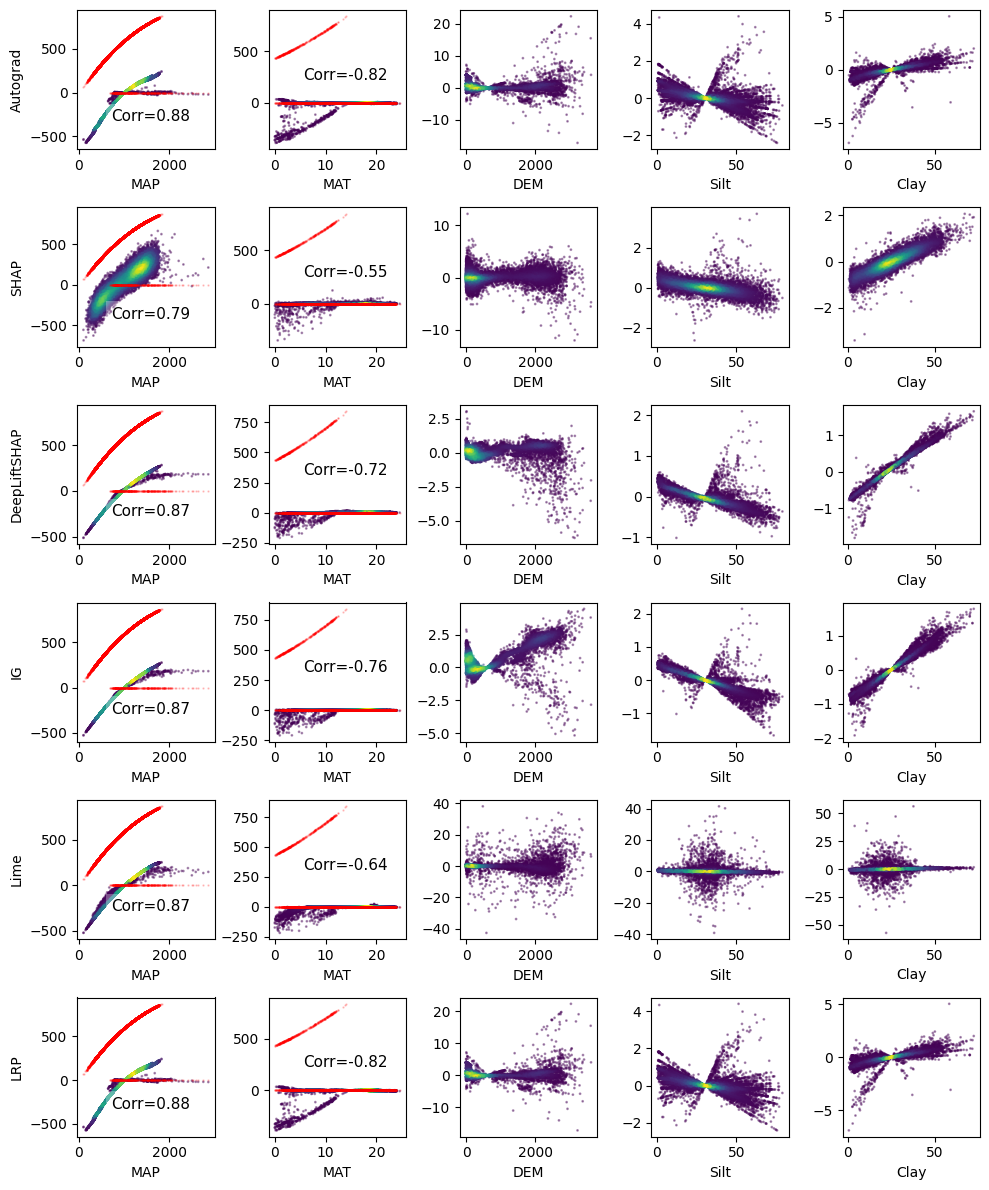

In [ ]:
# Execute and save matrix comparison distributions
autocontr = gradients_unscaled * all_fea_np * scaler.scale_
contri_arr = np.stack([autocontr, g_relevance, dl_relevance, ig_relevance, lime_relevance, lrp_relevance], axis=0)
contr_names = ["Autograd", "SHAP", "DeepLiftSHAP", "IG", "Lime", "LRP"]
plt_contr_var_multi(all_fea_raw, contri_arr, contr_names, var_names, save_fig=os.path.join(SAVE_PATH, 'contr_all.png'))

slope_arr shape: (6, 15000, 5)


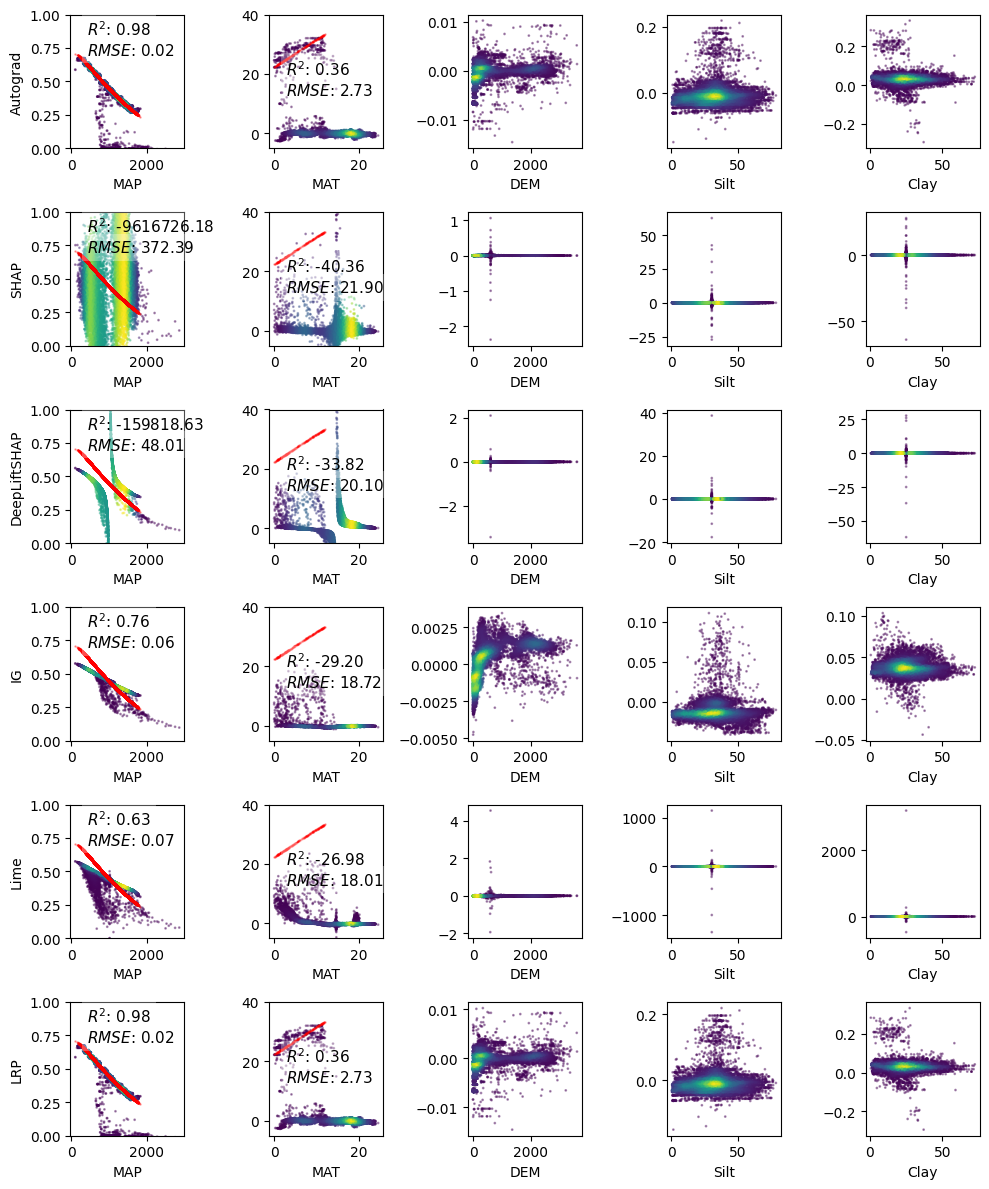

In [ ]:
GradientShap_slope = g_relevance / all_fea_np / scaler.scale_
DeepLiftShap_slope = dl_relevance / all_fea_np / scaler.scale_
IntegratedGradients_slope = ig_relevance / all_fea_np / scaler.scale_
Lime_slope = lime_relevance / all_fea_np / scaler.scale_
lpr_relevance_slope = lrp_relevance / all_fea_np / scaler.scale_
slope_arr = np.stack([gradients_unscaled, GradientShap_slope, DeepLiftShap_slope, IntegratedGradients_slope, Lime_slope, lpr_relevance_slope], axis=0)
slope_names = ["Autograd", "SHAP", "DeepLiftSHAP", "IG", "Lime", "LRP"]
plt_slope_var_multi(all_fea_raw, slope_arr, slope_names, var_names, save_fig=os.path.join(SAVE_PATH, 'slope_all.png'))

## 8. Analytical Validation using Symbolic Regression
Note: We used niterations=10000 and min_train=3000 in analysis, but it takes long time to run. For the demostratoin here, we set the niterations=1000 and min_train=1000.

In [ ]:
from pysr import PySRRegressor

/usr/local/lib/python3.12/dist-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/pysr/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] WARNING: You have Julia 1.12.6 installed but 1.10.3 - 1.11 is required.
[juliapkg]   It is recommended that you upgrade Julia or install JuliaUp.
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] WARNING: About to install Julia 1.11.9 to /root/.julia/environments/pyjuliapkg/pyjuliapkg/install.
[juliapkg]   If you use juliapkg in more than one environment, you are likely to
[juliapkg]   have Julia installed in multiple locations. It is recommended to
[juliapkg]   install JuliaUp (https://github.com/JuliaLang/juliaup) or Julia
[juliapkg]   (https://julialang.org/downloads) yourself.
[juliapkg] Downloading Julia

In [ ]:
def preprocessing_simu_sr(data_path:str, pca=True, standerize=True,train_portion=0.8, min_train=3000, nx=0, ny=0):
    """Preprocessing the simulated data for symbolic regression.

    Args:
        dataset (array): orginal data
        pca (bool, optional): If conduct PCA (Principal component analysis) transformation. Defaults to True.
        standerize (bool, optional): If standerize X variables. Defaults to True.
        train_portion (float, optional): split training test data. Defaults to 0.8.
        min_train (int, optional): minimum number of training data. Defaults to 3000.
        nx (float, optional): random noise added to X (noise STD = nx * var_std). Defaults to 0.
        ny (float, optional): random noise added to Y (noise STD = ny * y_std). Defaults to 0.

    Returns:
        train_x (array): Preprocessed X training data
        train_y (array): Preprocessed Y training data
        test_x (array): Preprocessed X test data
        test_y (array): Preprocessed Y test data
        scaler (object): The standardization scaler (see sklearn.preprocessing.StandardScaler)
        pca_model (object): The PCA object (see sklearn.decomposition.PCA)
    """
    df_slope = np.load(os.path.join(data_path, 'autograd_unscaled.npy'))
    prcp_slope_idx = df_slope[:, 0] > 0.2
    x_df = pd.read_csv(os.path.join(data_path, f'all_fea_raw.csv'))
    # if 'y' in x_df.columns:
    #   x_df = x_df.drop(columns='y')
    x_qa_idx = np.asarray([True]*len(x_df))
    for col in x_df.columns:
        if (nx != 0) and (col in ["prcp", "tmean"]):
            x_qa_idx = x_qa_idx * ((x_df[col]/(nx*np.std(x_df[col]))) > 20)
    fit_idx = prcp_slope_idx * x_qa_idx
    print(f"fit_idx: {np.sum(fit_idx)}")
    x_df = x_df[fit_idx]
    var_names = x_df.columns
    x_stack = x_df.to_numpy()
    print('x_stack.shape: ', x_stack.shape) # x_stack.shape:  (260388, 15)
    y_var = np.load(os.path.join(data_path, f'y_fea.npy'))[fit_idx]
    suf_idx = np.arange(x_stack.shape[0])
    np.random.shuffle(suf_idx)
    x_stack = x_stack[suf_idx, :]
    y_var = y_var[suf_idx]
    n_training = max(int(x_stack.shape[0] * train_portion), min_train)
    print('n_training: ', n_training)
    if standerize:
        scaler = joblib.load(os.path.join(data_path, "torch_scaler.bin"))
        x_stack = scaler.fit_transform(x_stack)

    else:
        scaler = None

    if pca:
        pca_model = PCA()  # n_components=2
        x_stack = pca_model.fit_transform(x_stack)
        # print('x_pca.shape=', x_pca.shape)

    train_x = x_stack[:n_training, :].copy()
    train_y = y_var[:n_training].copy()

    test_x = x_stack[n_training:, :].copy()
    test_y = y_var[n_training:].copy()
    print(train_x.shape, train_y.shape, test_x.shape, test_y.shape)
    if pca:
        return var_names, train_x, train_y, test_x, test_y, scaler, pca_model
    return var_names, train_x, train_y, test_x, test_y, scaler


def fit_PySRRegressor(data_path: str, sub_folder: str, nx=0, ny=0):
    var_names, train_x, train_y, _, _, _ = preprocessing_simu_sr(data_path=data_path, pca=False, standerize=False, train_portion=0.1, min_train=1000, nx=nx, ny=ny)
    df = pd.DataFrame(data=train_x, columns=var_names)
    if not os.path.exists(os.path.join(data_path, sub_folder)):
        os.makedirs(os.path.join(data_path, sub_folder))
    # print(train_x.shape, train_y.shape)
    df['response'] = train_y
    # print(df.head)

    dt_str = datetime.now().strftime("%Y%m%dT%H%M%S")
    # https://github.com/MilesCranmer/PySR/blob/master/pysr/sr.py
    model = PySRRegressor(
        niterations=1000,  # < Increase me for better results; used 10000 in manuscript analysis, but it takes many hours to complete
        maxsize=30, # Max complexity of an equation.  Default is `20`.
        binary_operators=["+", "-", "*", "/", "^"], #
        unary_operators=[
            "exp",
            # "log",
            # "sqrt",
        ],
        # temp_equation_file=True, #os.path.join(data_path, sub_folder, f"equation_{dt_str}.csv"), #  Where to save the files (.csv extension). Default is `None`.
        # tempdir=os.path.join(data_path, sub_folder), # directory for the temporary files.
        # delete_tempfiles=False,
        output_directory=os.path.join(data_path, sub_folder)
    )

    model.fit(df.drop(['response'], axis=1), df['response'])


def load_model(eq_path: str):
    return PySRRegressor.from_file(run_directory=eq_path) # model


def eval_eq_str_slope(model, eq_idx:int, df_x, df_slope, valid_idx, step=0.0001, slope_out=None)->float:
    # model = load_model(eq_path)
    # print(model.equations_.sympy_format[eq_idx])
    eq_slope = df_x.copy()
    loss_der = []
    for n in range(len(df_x.columns)):
        df_x.iloc[:, n] -= step
        pred_pre = model.predict(df_x, eq_idx)
        df_x.iloc[:, n] += 2 * step
        pred_pos = model.predict(df_x, eq_idx)
        df_x.iloc[:, n] -= step
        df_y = model.predict(df_x, eq_idx)
        # print(df_x.columns[n], sum(abs(pred_pre-df_y)), sum(abs(df_y-pred_pos)))
        if (sum(abs(pred_pre-df_y))!=0) | (sum(abs(df_y-pred_pos))!=0): #(sum(abs(pred_pre-pred_pos))!=0) |
            der = (pred_pos - pred_pre)/(2*step)
            eq_slope.iloc[:, n] = der
            diffs = der[valid_idx] - df_slope[valid_idx, n]
            rmse_der = np.sqrt(sum(diffs ** 2) / len(diffs)) / np.std(df_slope[valid_idx, n]) # np.std(df_x.iloc[:, n])
            # print(df_x.columns[n], rmse_der)
            # println(size(der), size(diffs), size(rmse_der), rmse_der)
            loss_der.append(rmse_der)
        else:
            eq_slope.iloc[:, n] *= 0
    if slope_out:
        eq_slope.to_csv(slope_out)
    # return rmse
    # print(model.equations_["equation"][eq_idx], loss_der)
    if len(loss_der) == 0:
        return None
    return sum(loss_der) /len(loss_der)


def eval_PySRRegressor(model_dir: str, sub_folder: str, nx):
    # model_dir = os.path.join(SAVE_PATH, dnn_folder)
    # eq_files = glob(os.path.join(model_dir, sub_folder, "**", "hall_of_fame.csv"), recursive=True)
    eq_files = glob(os.path.join(model_dir, sub_folder, "*/"), recursive=True)
    if len(eq_files)==0:
        print(f"eval_PySRRegressor: No equation found in {model_dir} {sub_folder}")
        return

    df = pd.read_csv(os.path.join(model_dir, 'all_fea_raw.csv')).dropna()
    # df = df.drop(columns='y')
    print(df.head())
    df_slope = np.load(os.path.join(model_dir, 'autograd_unscaled.npy'))
    train_y = np.load(os.path.join(model_dir, 'y_fea.npy')).squeeze()
    prcp_idx = df_slope[:, 0] > 0.2
    x_qa_idx = np.asarray([True]*len(df))
    # nx = float(os.path.basename(model_dir).split('_')[1][2:])
    for col in df.columns:
        if (nx != 0) and (col in ["prcp", "tmean"]):
            x_qa_idx = x_qa_idx * ((df[col]/(nx*np.std(df[col]))) > 20)
    fit_idx = prcp_idx * x_qa_idx
    print(f"nx: {nx}, fit_idx: {np.sum(fit_idx)}")
    # df = df[fit_idx]
    # df_slope = df_slope[fit_idx, :]
    # train_y = train_y[fit_idx]
    model_eval = []
    for m in eq_files:
        # print(m)
        # eq_path = os.path.join(data_dir, m)
        model = load_model(m)
        # print(model.equations_)
        for i in range(len(model.equations_)):
            mad = np.mean(np.abs(model.predict(df, i) - train_y))
            rmse_std = np.sqrt(np.mean((model.predict(df, i) - train_y)**2)) / np.std(train_y)
            loss_partial = eval_eq_str_slope(model, i, df, df_slope, fit_idx)
            if loss_partial is None:
                model_eval.append({"model_path": m, "model_index": i, "Equation": model.equations_.sympy_format[i], "ADVISE_loss": None, "PySR_Score": model.equations_.score[i]})
            else:
                model_eval.append({"model_path": m, "model_index": i, "Equation": model.equations_.sympy_format[i], "ADVISE_loss": (loss_partial + rmse_std), "PySR_Score": model.equations_.score[i]})
            # print(eval_eq_str_slope(eq_path, i, df, train_y, df_slope))
    df_model_eval = pd.DataFrame(model_eval)
    # print("Summary df: \n", df.head(), "\n")
    df_model_eval.to_csv(os.path.join(model_dir, sub_folder, f"model_summary.csv"))

    max_score = df_model_eval["PySR_Score"].idxmax()
    min_new = df_model_eval["ADVISE_loss"].idxmin()
    with open(os.path.join(SAVE_PATH, "sym_model.txt"), "a") as file:
        org_model = load_model(df_model_eval.loc[max_score]["model_path"]).equations_.sympy_format[df_model_eval.loc[max_score]["model_index"]]
        new_model = load_model(df_model_eval.loc[min_new]["model_path"]).equations_.sympy_format[df_model_eval.loc[min_new]["model_index"]]
        file.writelines(f"Original, {org_model}\n")
        file.writelines(f"New, {new_model}\n")
    ## Validation ##
    org_pred = load_model(df_model_eval.loc[max_score]["model_path"]).predict(df, df_model_eval.loc[max_score]["model_index"])
    new_pred = load_model(df_model_eval.loc[min_new]["model_path"]).predict(df, df_model_eval.loc[min_new]["model_index"])
    org_slope_name = os.path.join(model_dir, sub_folder, f"org_symbolic_slope.csv")
    eval_eq_str_slope(load_model(df_model_eval.loc[max_score]["model_path"]), df_model_eval.loc[max_score]["model_index"], df, df_slope, fit_idx, slope_out=org_slope_name)
    new_slope_name = os.path.join(model_dir, sub_folder, f"new_symbolic_slope.csv")
    eval_eq_str_slope(load_model(df_model_eval.loc[min_new]["model_path"]), df_model_eval.loc[min_new]["model_index"], df, df_slope, fit_idx, slope_out=new_slope_name)
    sym_org_rmse = np.sqrt(np.mean(np.square(train_y - org_pred)))
    sym_new_rmse = np.sqrt(np.mean(np.square(train_y - new_pred)))
    dnn_pred = np.load(os.path.join(model_dir, "predictions.npy")).flatten()# [fit_idx]
    dnn_rmse = np.sqrt(np.mean(np.square(train_y - dnn_pred))) #.values.flatten()
    print(f"pySR_Sym RMSE:", sym_org_rmse, " ADVISE_Sym RMSE:", sym_new_rmse, " DNN RMSE:", dnn_rmse)
    pd.DataFrame({"DNN_true": train_y, "DNN_pred": dnn_pred, "Sym_pySR": org_pred, "Sym_ADVISE": new_pred, "Sym_idx": fit_idx}).to_csv(os.path.join(model_dir, sub_folder, f"Prediction_compare.csv"))



def extract_final_eq(model_dir: str, sub_folder: str):
    df = pd.DataFrame(columns=["pySR", "ADVISE"])
    model_dir = os.path.join(model_dir, sub_folder, f"model_summary.csv")
    if not os.path.exists(model_dir):
        print(f"extract_final_eq: No model found in {model_dir}")
        return
    df_model = pd.read_csv(model_dir)
    max_score = df_model["PySR_Score"].idxmax()
    min_new = df_model["ADVISE_loss"].idxmin()
    org_model = df_model.loc[max_score]["Equation"]
    new_model = df_model.loc[min_new]["Equation"]
    rec = pd.DataFrame([{"pySR": org_model, "ADVISE": new_model}])
    df = pd.concat([df, rec], ignore_index=True)
    df.to_csv(os.path.join(os.path.dirname(model_dir), "final_eq.csv"), index=False)
    return df

In [ ]:
# Run evaluation pipeline
fit_PySRRegressor(data_path=SAVE_PATH, sub_folder="pySR", nx=0, ny=0)
eval_PySRRegressor(model_dir=SAVE_PATH, sub_folder="pySR",  nx=0)
final_eq = extract_final_eq(model_dir=SAVE_PATH, sub_folder="pySR")
print(final_eq)

fit_idx: 14647
x_stack.shape:  (14647, 5)
n_training:  1464
(1464, 5) (1464, 1) (13183, 5) (13183, 1)


/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!


Streaming output truncated to the last 5000 lines.
20          7.647e-02  4.337e-02  y = (18.998 - prcp) * (((-175.7 - (prcp * -0.030292)) / ((...
                                      prcp ^ 0.49023) + 210.96)) - exp(prcp * -0.023156))
22          7.646e-02  5.344e-05  y = (((-175.7 - (prcp * -0.030292)) / (210.96 + (prcp ^ 0....
                                      49023))) - exp((prcp - 0.73081) * -0.023156)) * (18.998 - ...
                                      prcp)
24          7.551e-02  6.240e-03  y = (18.992 - prcp) * (((-175.7 - (prcp * -0.030235)) / ((...
                                      prcp ^ ((-37066 / exp(prcp ^ 0.49156)) + 0.49155)) + 210.9...
                                      6)) - 0.00041249)
26          7.508e-02  2.851e-03  y = (((-175.7 - (prcp * -0.030252)) / ((prcp ^ (((prcp / e...
                                      xp(prcp ^ 0.4914)) * -175.7) + 0.4914)) + 210.96)) - 0.000...
                                      44371) * (19.04 - prcp)
28          7

[ Info: Final population:
[ Info: Results saved to:
Attempting to load model from outputs/pySR/20260602_164019_DI114X/checkpoint.pkl...
INFO:pysr.sr:Attempting to load model from outputs/pySR/20260602_164019_DI114X/checkpoint.pkl...


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.485e+04  0.000e+00  y = 565.18
3           1.085e+03  1.733e+00  y = prcp ^ 0.9166
5           1.421e+02  1.016e+00  y = (prcp * 4.2134) ^ 0.76224
7           6.592e-01  2.687e+00  y = prcp * ((prcp * -0.00014459) + 0.7376)
9           6.424e-01  1.292e-02  y = (((prcp + 0.73759) * 0.99986) - prcp) * prcp
11          6.291e-01  1.045e-02  y = (0.89671 - prcp) * ((prcp * -0.99985) + (prcp - 0.7389...
                                      2))
13          5.983e-01  2.507e-02  y = (-163.24 - (prcp * -0.032143)) * ((2.6115 / prcp) - (p...
                                      rcp / 220.86))
15          9.498e-02  9.202e-01  y = (19.065 - prcp) * ((-176.46 - (prcp * -0.030154)) / ((...
                                      prcp ^ 0.49552) + 211.34))
17          9.382e-02  6.135e-03  y = (((-28.969 - (prcp * -0.025975)) / ((prcp ^ 0.5233

Attempting to load model from outputs/pySR/20260602_170137_MyOriT/checkpoint.pkl...
INFO:pysr.sr:Attempting to load model from outputs/pySR/20260602_170137_MyOriT/checkpoint.pkl...
Attempting to load model from outputs/pySR/20260602_165613_ICd6TU/checkpoint.pkl...
INFO:pysr.sr:Attempting to load model from outputs/pySR/20260602_165613_ICd6TU/checkpoint.pkl...
Attempting to load model from outputs/pySR/20260602_165613_ICd6TU/checkpoint.pkl...
INFO:pysr.sr:Attempting to load model from outputs/pySR/20260602_165613_ICd6TU/checkpoint.pkl...
Attempting to load model from outputs/pySR/20260602_170137_MyOriT/checkpoint.pkl...
INFO:pysr.sr:Attempting to load model from outputs/pySR/20260602_170137_MyOriT/checkpoint.pkl...
Attempting to load model from outputs/pySR/20260602_165613_ICd6TU/checkpoint.pkl...
INFO:pysr.sr:Attempting to load model from outputs/pySR/20260602_165613_ICd6TU/checkpoint.pkl...
Attempting to load model from outputs/pySR/20260602_170137_MyOriT/checkpoint.pkl...
INFO:pysr.s

pySR_Sym RMSE: 19.134086597181  ADVISE_Sym RMSE: 19.491563339860065  DNN RMSE: 1.4935411561554728
                                    pySR  \
0  prcp*(0.7375108 - 0.00014452652*prcp)   

                                              ADVISE  
0  (19.002348 - prcp)*(-1.01706629045295*exp(-0.0...  
  - ./outputs/pySR/20260602_170137_MyOriT/hall_of_fame.csv
